In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver

In [ ]:
sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = SpinBoson({
    'V':0.5,
    'E':0.5,
    'A':10,
    'W':0.1,
    'l_reorg':0.05,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = MeanField()

def calc_adb_pops(sim, state, parameters):
    h = state["h_q_tot"]
    evals, evecs = np.linalg.eigh(h)
    wf_adb = np.einsum('tia,ti->ta', evecs.conj(), state["wf_db"])
    state["output_dict"]["adb_pops"] = np.abs(wf_adb)**2
    return state, parameters

sim.algorithm.collect_recipe.append(calc_adb_pops)

sim.initial_state["wf_db"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

t = data.data_dict['t']
pops_adb = np.real(data.data_dict['adb_pops'])
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField, AbInitioMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.0001
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#


sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

In [3]:
import numpy as np
A = np.array([{} for a in range(10)])
print(A)
print(A.dtype)

[{} {} {} {} {} {} {} {} {} {}]
object


In [ ]:
print(etot-etot[0])

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-0*ec[0], label='Classical Energy')
plt.plot(t, eq-0*eq[0], label='Quantum Energy')
plt.plot(t, etot-0*etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation, functions # import simulation class 
from qclab.models import SpinBoson#, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AbInitioFewestSwitchesSurfaceHopping # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 1
sim.settings.tmax = 15
sim.settings.dt_update = 0.01
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':10,
    'W':0.1,
    'l_reorg':0.5,
    'boson_mass':1.0,
    'kBT':1.0,
})

def collect_qp(sim, state, parameters):
    m = sim.model.constants.classical_coordinate_mass
    h = sim.model.constants.classical_coordinate_weight
    p = functions.z_to_p(state["z"], m[np.newaxis], h[np.newaxis])
    q = functions.z_to_q(state["z"], m[np.newaxis], h[np.newaxis])
    state["output_dict"]["q"] = q
    state["output_dict"]["p"] = p
    state["output_dict"]["energy"] = np.einsum('tii->ti',state["h_q_tot"])
    state["output_dict"]["wf_adb"] = state["wf_adb"]
    return state, parameters

# sim.algorithm = AbInitioMeanField({"update_wf_adb_eig_num_substeps":10})#AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#
sim.algorithm = AbInitioFewestSwitchesSurfaceHopping({"update_wf_adb_eig_num_substeps":100})
sim.algorithm.collect_recipe.append(collect_qp)

sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

NameError: name 'AdiabaticSpinBoson' is not defined

In [4]:
import numpy as np

print(np.exp(1.0j*(-1e-11)))
print(np.exp(1j*(1e-11)))

(1-1e-11j)
(1+1e-11j)


In [5]:
data1 = data

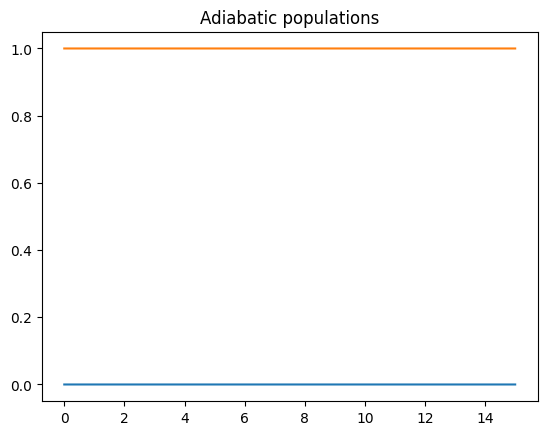

/Users/akrotz/Research/qclab-dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/akrotz/Research/qclab-dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


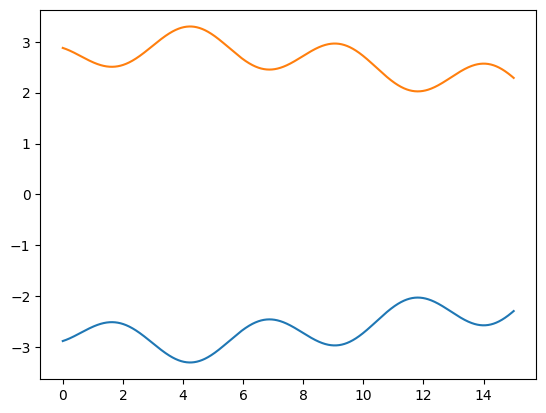

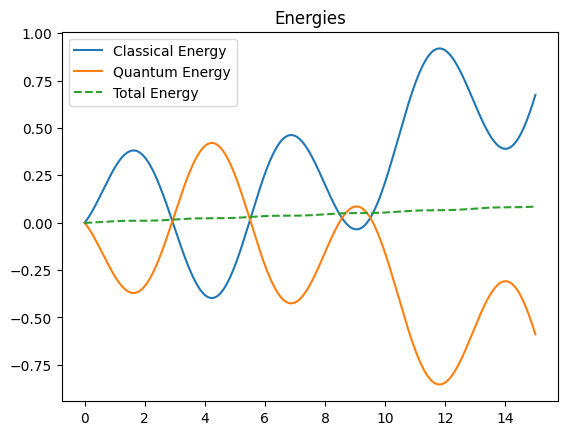

In [2]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
pops_adb = np.real(np.einsum('tii->ti', data.data_dict['dm_db']))
energy = data.data_dict['energy']
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()
plt.plot(t, energy)
plt.show()
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

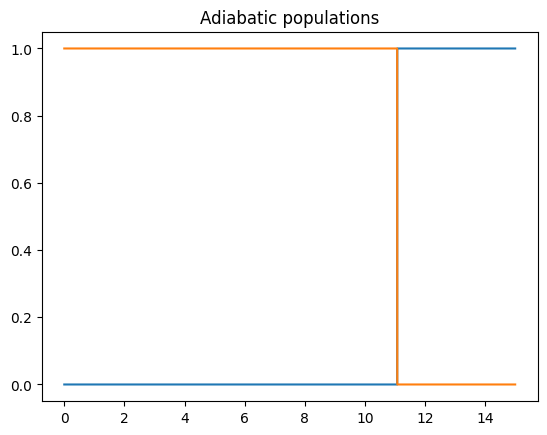

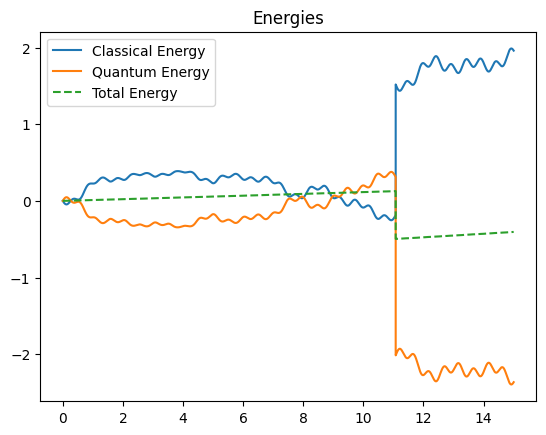

In [2]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
pops_adb = np.real(np.einsum('tii->ti', data.data_dict['dm_db']))
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()

etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation, functions # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AbInitioFewestSwitchesSurfaceHopping # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 1
sim.settings.tmax = 15
sim.settings.dt_update = 0.01
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':10,
    'W':0.1,
    'l_reorg':0.5,
    'boson_mass':1.0,
    'kBT':1.0,
})

def collect_qp(sim, state, parameters):
    m = sim.model.constants.classical_coordinate_mass
    h = sim.model.constants.classical_coordinate_weight
    p = functions.z_to_p(state["z"], m[np.newaxis], h[np.newaxis])
    q = functions.z_to_q(state["z"], m[np.newaxis], h[np.newaxis])
    state["output_dict"]["q"] = q
    state["output_dict"]["p"] = p
    state["output_dict"]["energy"] = np.einsum('tii->ti',state["h_q_tot"])
    state["output_dict"]["wf_adb"] = state["wf_adb"]
    return state, parameters

# sim.algorithm = AbInitioMeanField({"update_wf_adb_eig_num_substeps":10})#AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#
sim.algorithm = AbInitioFewestSwitchesSurfaceHopping({"update_wf_adb_eig_num_substeps":100})
sim.algorithm.collect_recipe.append(collect_qp)

sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

# data = serial_driver(sim)
print(10)
# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

10
